# Exploratory Data Analysis

## Data overview and missing values

### Packages and loading data

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Ensure data is saved in working directory folder. Create df_test to alter without affect original df.

In [34]:
df = pd.read_csv("train.csv", index_col = "Id")

df_test = df

### Overview of data

Look at df shape and missing value counts.

In [35]:
print("df shape: ", df.shape)
print("Missing values: \n", df.isnull().sum().sort_values(ascending=False))
print("Data types: \n", df.dtypes.value_counts())

df shape:  (1460, 80)
Missing values: 
 PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 80, dtype: int64
Data types: 
 str        43
int64      34
float64     3
Name: count, dtype: int64


Look at data types by creating a new df that groups by data type.

In [36]:
dtype_df = df.dtypes.astype(str).reset_index()
dtype_df.columns = ['Column', 'Data type']

grouped = dtype_df.groupby('Data type')['Column'].apply(list)

wide_df = pd.DataFrame({
    dtype: pd.Series(cols)
    for dtype, cols in grouped.items()
})

wide_df

,float64,int64,str
0,LotFrontage,MSSubClass,MSZoning
1,MasVnrArea,LotArea,Street
2,GarageYrBlt,OverallQual,Alley
3,NaN,OverallCond,LotShape
4,NaN,YearBuilt,LandContour
5,NaN,YearRemodAdd,Utilities
6,NaN,BsmtFinSF1,LotConfig
7,NaN,BsmtFinSF2,LandSlope
8,NaN,BsmtUnfSF,Neighborhood
9,NaN,TotalBsmtSF,Condition1


Some features required converting to categorical.

In [37]:
df_test["MoSold"] = df_test["MoSold"].astype("str")
df_test["MSSubClass"] = df_test["MSSubClass"].astype("str")

### Target variable exploration

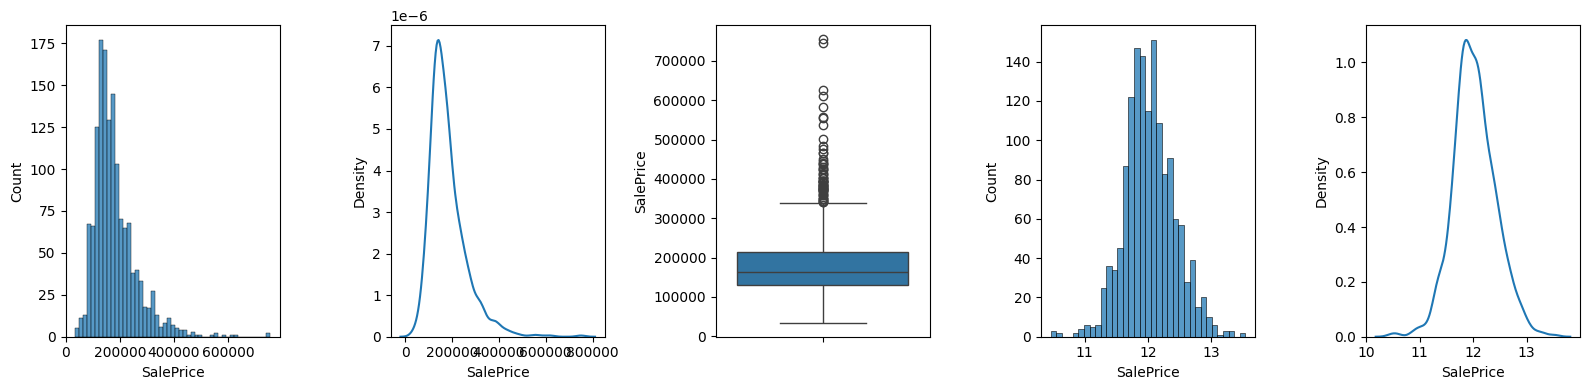

In [38]:
fig, axes = plt.subplots(ncols=5, figsize = (16, 4)) 

sns.histplot(df["SalePrice"], ax=axes[0])
sns.kdeplot(df["SalePrice"], ax=axes[1])
sns.boxplot(df["SalePrice"], ax=axes[2])
sns.histplot(np.log1p(df["SalePrice"]), ax=axes[3])
sns.kdeplot(np.log1p(df["SalePrice"]), ax=axes[4])

plt.tight_layout()
plt.show()

Since house prices appear normally distributed under log transform, the new target variable will be log(SalePrice), to be converted back to SalePrice after prediction.

### Missing values

Sort columns by missing value count.

In [39]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Fill appropriate missing values with None.

In [ ]:
cols_to_fill_with_NA = ["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu", "GarageType", "GarageQual", "GarageCond", "BsmtExposure", "BsmtFinType2", "BsmtQual", "BsmtCond", "BsmtFinType1", "GarageFinish"]

df_test[cols_to_fill_with_NA] = df_test[cols_to_fill_with_NA].fillna("None")

Fill missing lot frontage with median for neighbourhood.

In [41]:
df_test["LotFrontage"] = df_test.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

Fill MasVnrArea by median of MasVnrType.

In [42]:
df_test['MasVnrArea'] = df_test['MasVnrArea'].fillna(
    df_test.groupby('MasVnrType')['MasVnrArea'].transform('median')
)

Garage age is missing for when garage does not exist, so create a new variable has_garage, which if false has garage_age 0.

In [43]:
df_test["has_garage"] = df_test["GarageYrBlt"].notnull().astype(bool)
df_test["garage_age"] = df_test["YrSold"] - df_test["GarageYrBlt"]
df_test["garage_age"] = df_test["garage_age"].fillna(0)

Create a list of columns to be dropped, starting with GarageYrBlt.

In [47]:
cols_to_drop = ["GarageYrBlt"]

In [48]:
df_test = df_test.drop(columns="GarageYrBlt")

Check missingness after imputation.

In [49]:
df_test.isnull().sum().sum()

np.int64(0)

## Numeric features

### Numeric feature distributions

Count the number of numeric features, excluding sale price.

In [59]:
numeric_cols = df_test.drop(columns = "SalePrice").select_dtypes(np.number).columns

print("Numeric columns: ", len(numeric_cols))

Numeric columns:  34


34 numeric features, so plot distributions in 6 x 6 grid.

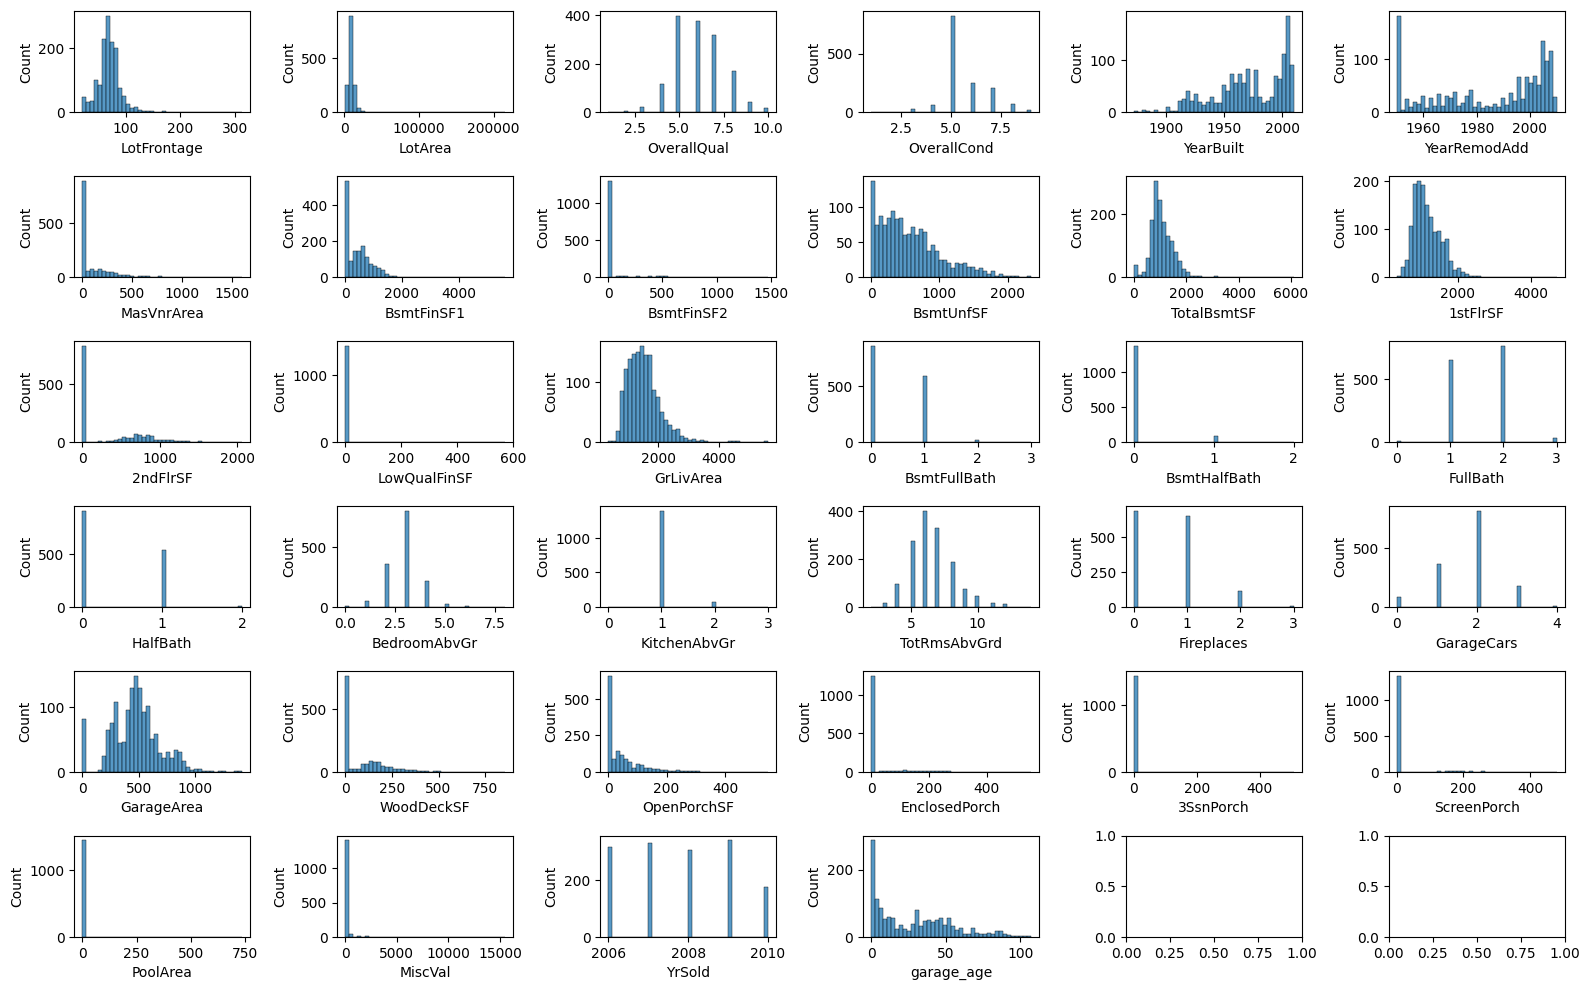

In [ ]:
fig, axes = plt.subplots(6, 6, sharex = False, sharey = False, figsize = (16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins = 40, ax = axes[i])

plt.tight_layout()
plt.show()

Many heavily skewed features - implies tree based model will be more appropriate. Many of these features can be converted to binary e.g. has_pool.

Look at numeric features vs sale price scatterplots to initially identify patterns.

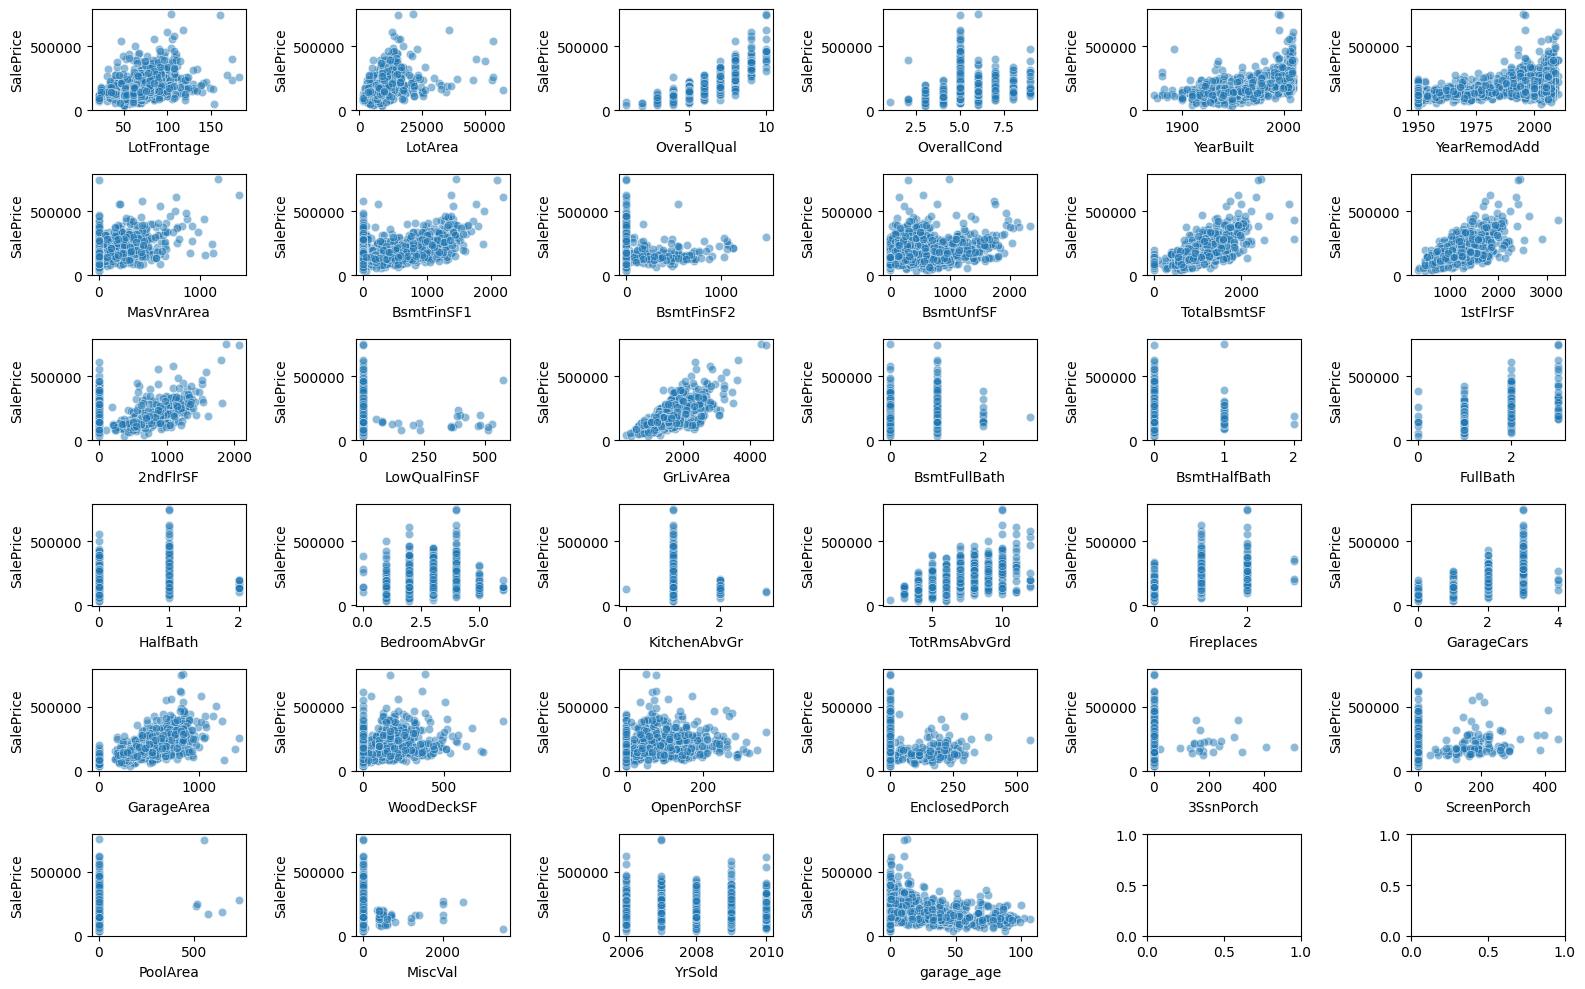

In [ ]:
fig, axes = plt.subplots(6, 6, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(x=df_test[col], y=df_test["SalePrice"], alpha=0.5, ax = axes[i])

plt.tight_layout()
plt.show()

### Outliers

Scatterplots show obvious outliers, these should be more closely inspected where necessary and then removed.

In [ ]:
# GrLivArea outliers

df[["GrLivArea", "SalePrice"]].sort_values(by="GrLivArea", ascending=False).head()

,GrLivArea,SalePrice
Id,,
1299,5642,160000
524,4676,184750
1183,4476,745000
692,4316,755000
1170,3627,625000


In [ ]:
# MiscVal outliers

df[["MiscVal", "SalePrice"]].sort_values(by="MiscVal", ascending=False).head()

,MiscVal,SalePrice
Id,,
347,15500,151500
1231,8300,190000
706,3500,55000
1458,2500,266500
511,2000,164900


In [ ]:
# Remove obvious outliers

df_test = df_test[
    (df["LotFrontage"] < 300) &
    (df["LotArea"] < 100000) &
    (df["BsmtFinSF1"] < 4000) &
    (df["TotalBsmtSF"] < 6000) &
    (df["GrLivArea"] < 4676) &
    (df["MiscVal"] < 8300) &
    (df["BedroomAbvGr"] < 8) &
    (df["LotArea"] < 70000) &
    (df["MasVnrArea"] < 1400) &
    (df["OpenPorchSF"] < 400)
]

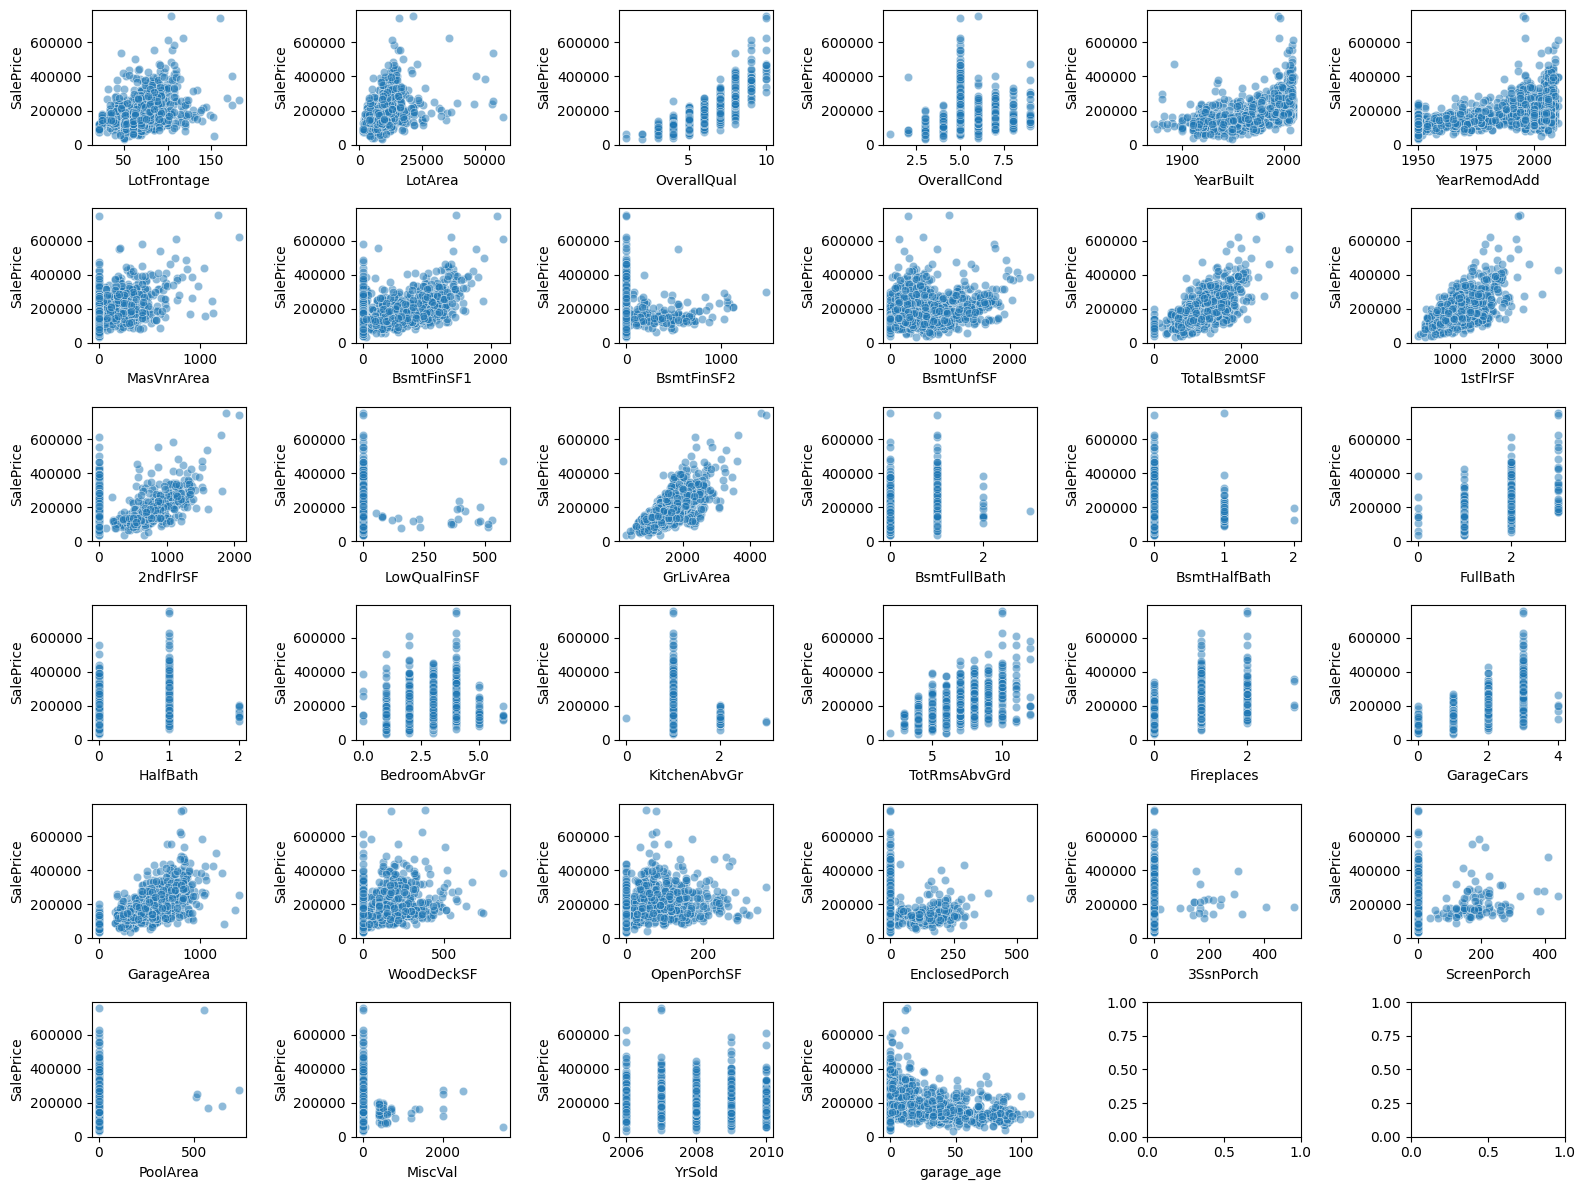

In [63]:
# Re check feature vs sale price after outlier removal

fig, axes = plt.subplots(6, 6, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(x=df_test[col], y=df_test["SalePrice"], alpha=0.5, ax = axes[i])

plt.tight_layout()
plt.show()

### Numeric feature correlations

Scatterplots show some strong features, these can be quantified with correlation strength.

In [69]:
top_features = df_test.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
top_features.head(8)

SalePrice      1.000000
OverallQual    0.797295
GrLivArea      0.737981
TotalBsmtSF    0.650411
GarageCars     0.643279
GarageArea     0.629946
1stFlrSF       0.629042
FullBath       0.558970
Name: SalePrice, dtype: float64

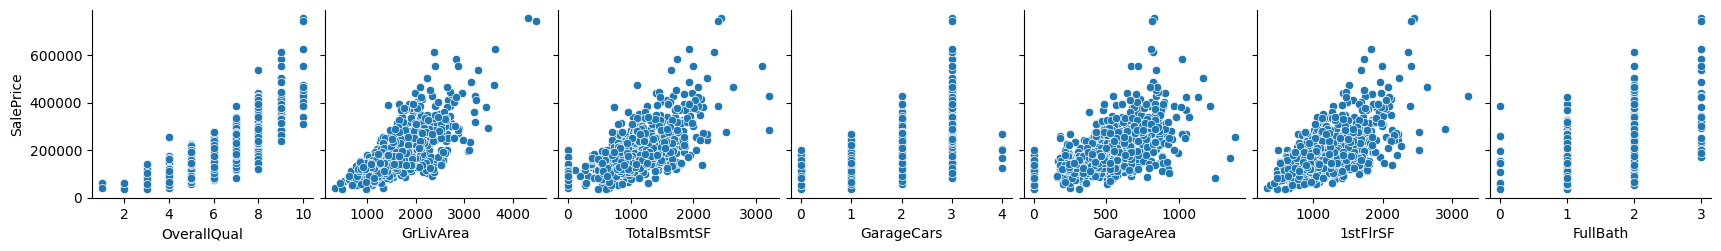

In [70]:
sns.pairplot(data=df_test, x_vars=top_features.index[1:8], y_vars=["SalePrice"])

This shows strongs relationships between these features and target. Next check least import features to confirm no relationship.

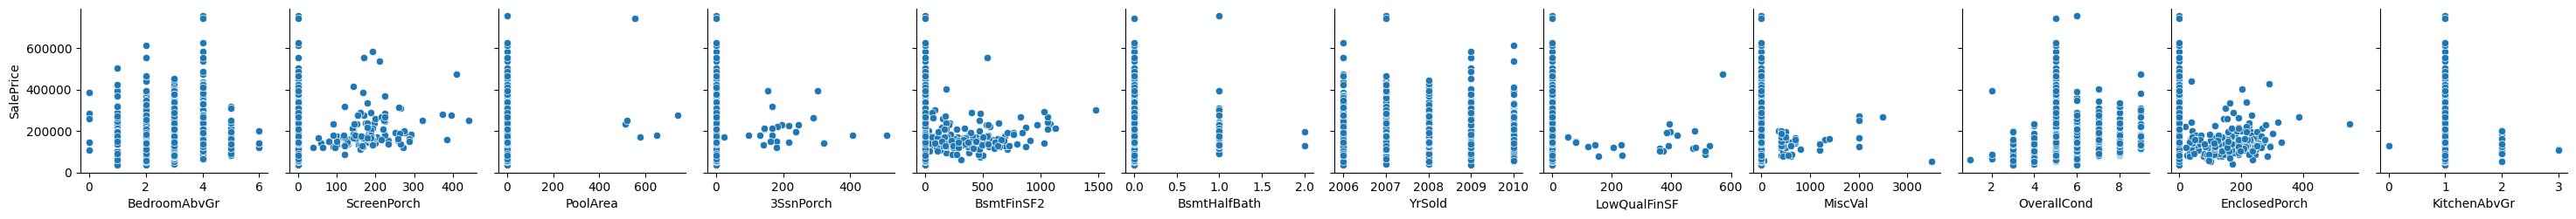

In [73]:
low_correlation_features = top_features[np.abs(top_features) < 0.2]

sns.pairplot(data=df_test, x_vars=low_correlation_features.index, y_vars=["SalePrice"])

Some features are massively skewed or have no relationship with sale price, required engineering or exclusion from the model.

Construct correlation matrix to inspect feature to feature relationships.

<Axes: >

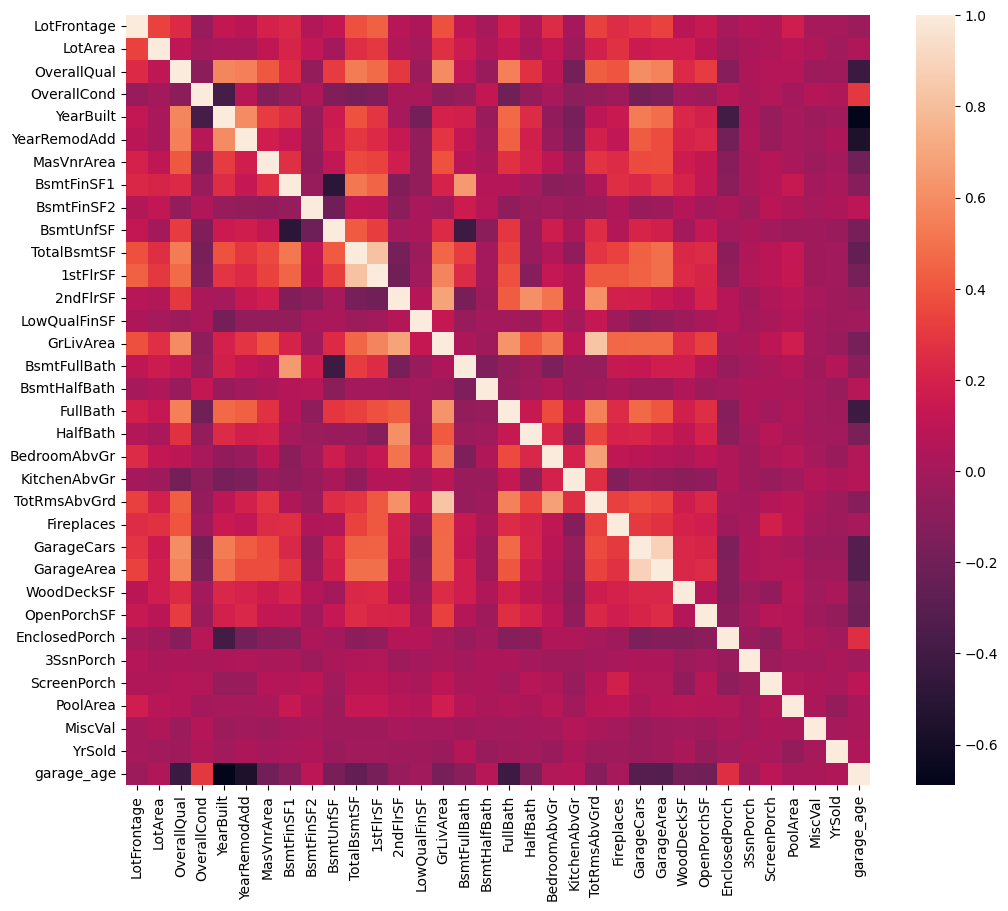

In [74]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr)

Many features are correlated, suggesting linear models are unsuitable.

### Numeric feature engineering

Convert massively skewed features into binary where appropriate. Keep 2nd floor SF as still important feature.

In [ ]:
df_test["has_second_floor"] = df_test["2ndFlrSF"]

features_to_binary = ["has_second_floor", "3SsnPorch", "ScreenPorch", "PoolArea", "EnclosedPorch"]

for col in features_to_binary:
    df_test[col] = df_test[col] > 0

Now derive a house_age feature.

In [76]:
df_test["house_age"] = df_test["YrSold"] - df_test["YearBuilt"]

cols_to_drop.append("YrSold")
cols_to_drop.append("YearBuilt")

Remove features that clearly have no relationship with sale price or will negatively impact model performance.

In [77]:
cols_to_drop.append("BedroomAbvGr")
cols_to_drop.append("BsmtFinSF2")
cols_to_drop.append("BsmtHalfBath")
cols_to_drop.append("LowQualFinSF")
cols_to_drop.append("MiscVal")
cols_to_drop.append("KitchenAbvGr")
cols_to_drop.append("BsmtFullBath")
cols_to_drop.append("HalfBath")

## Categorical features

### Categorical feature distributions

Count number of categorical columns (this has increased due to numeric feature engineering).

In [ ]:
cat_cols = df_test.select_dtypes(include=['object', 'category', 'str']).columns

print("Categorical columns: ", len(cat_cols))

Categorical columns:  45


Plot the cat feature distributinos in 9 x 5 grid.

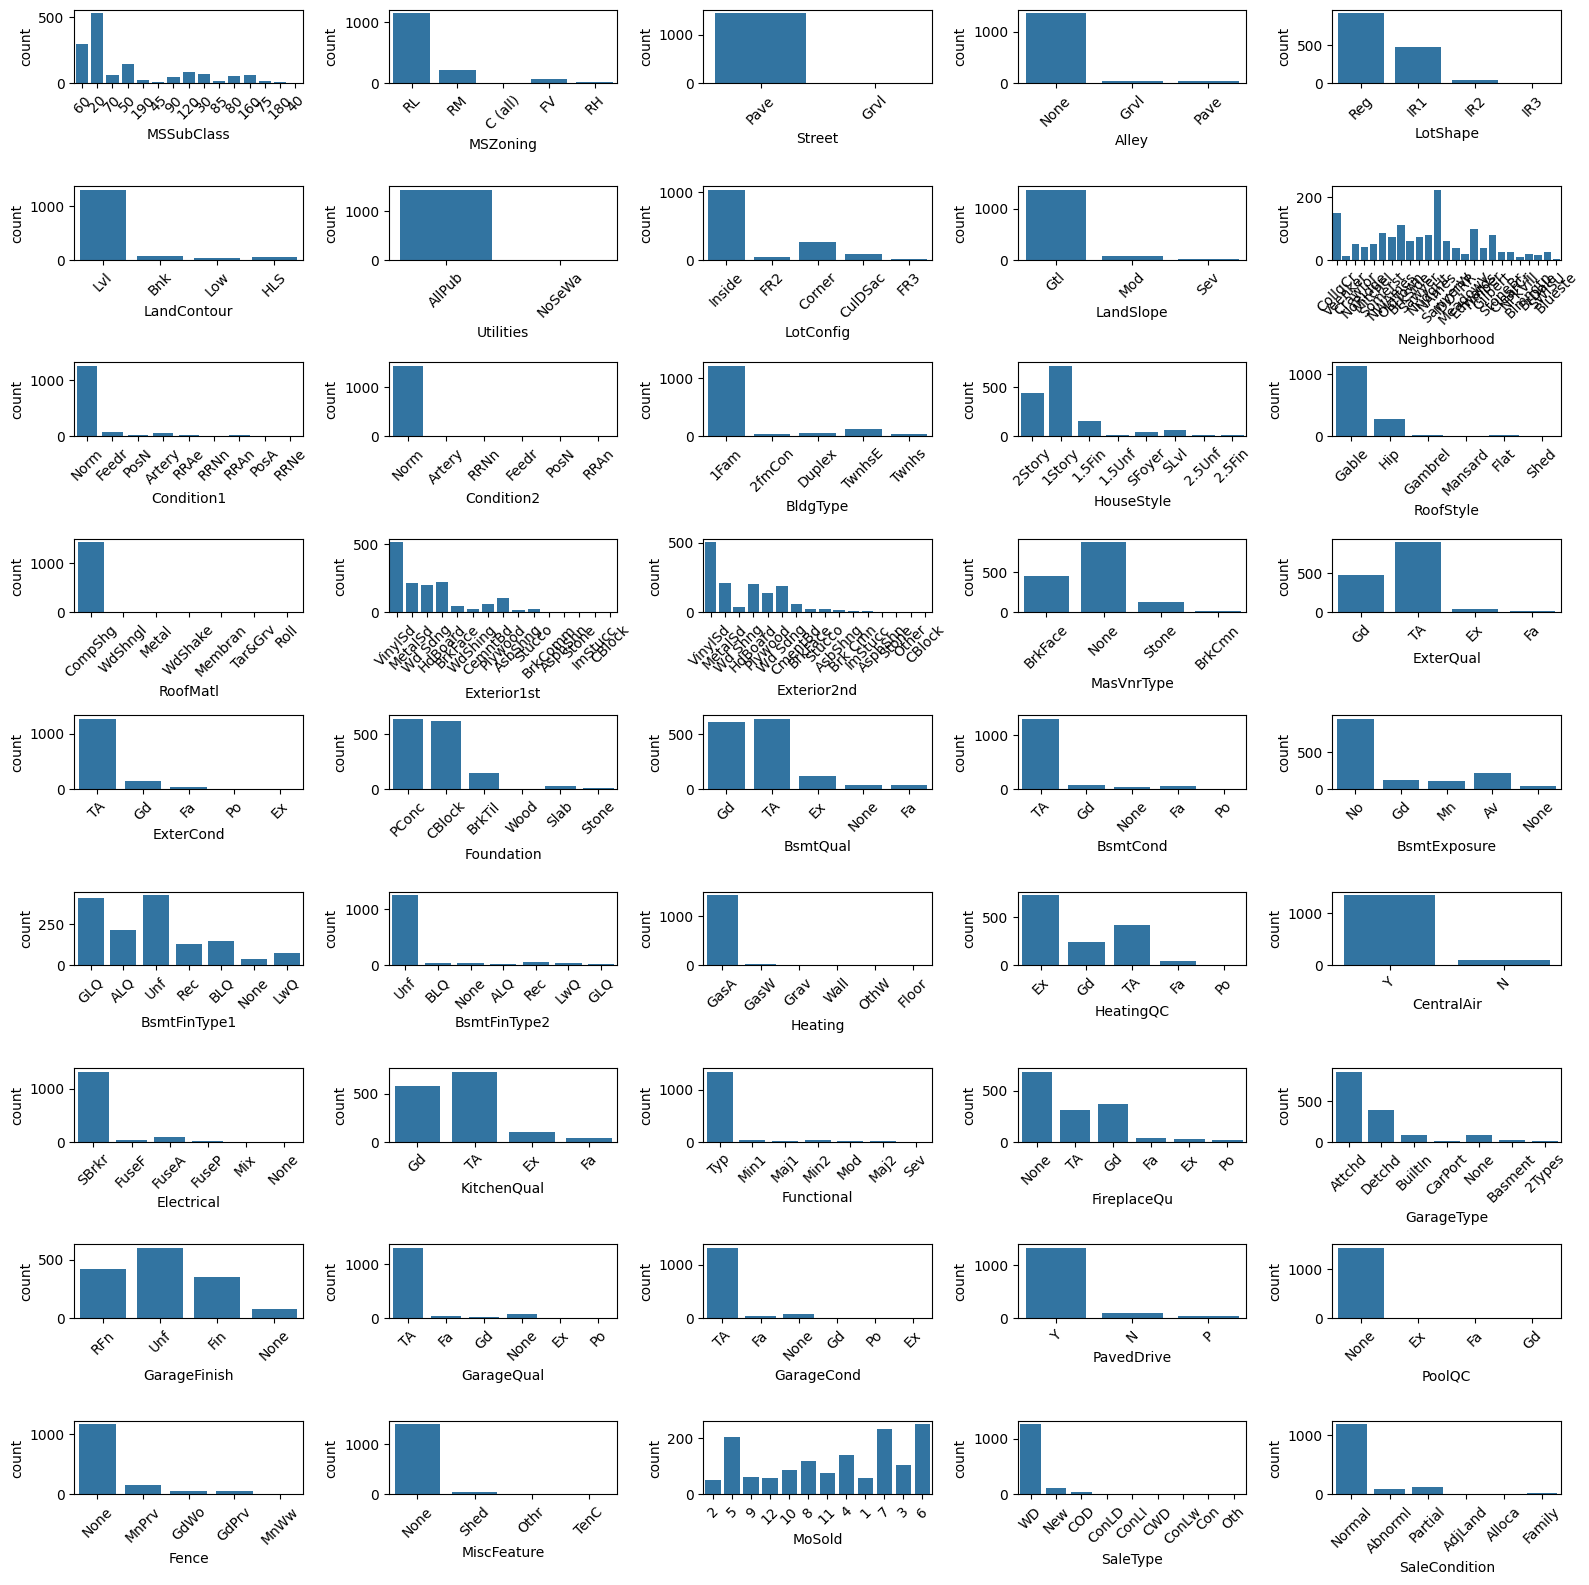

In [82]:
fig, axes = plt.subplots(9, 5, sharex = False, sharey = False, figsize = (16, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x = col, data = df_test, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    
plt.tight_layout()
plt.show()

Some features are massively skewed, check the boxplots for the categories and ANOVA if further inspection required.

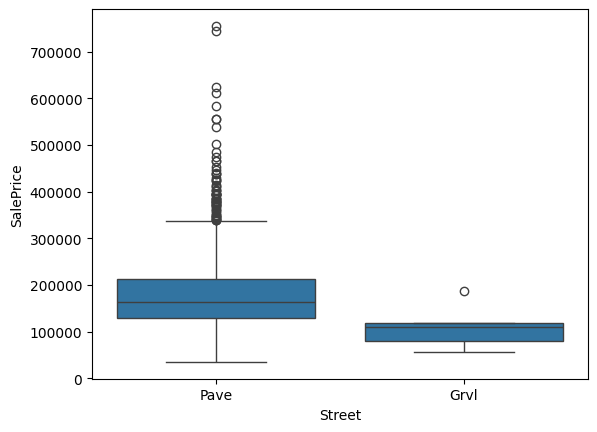

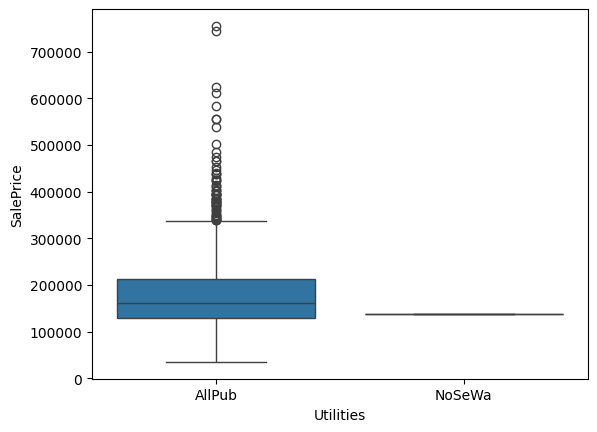

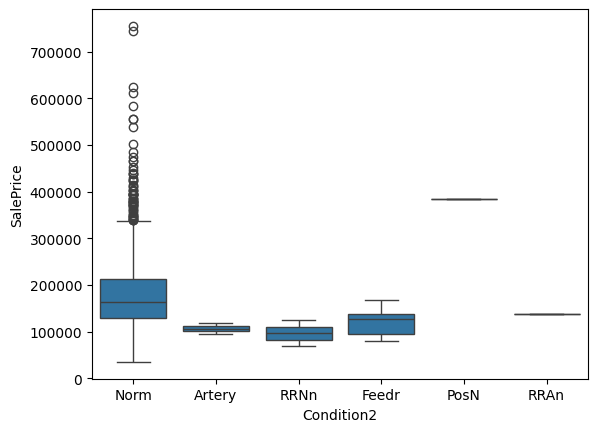

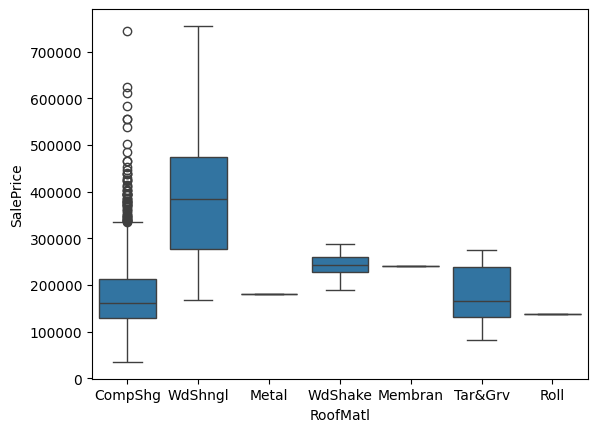

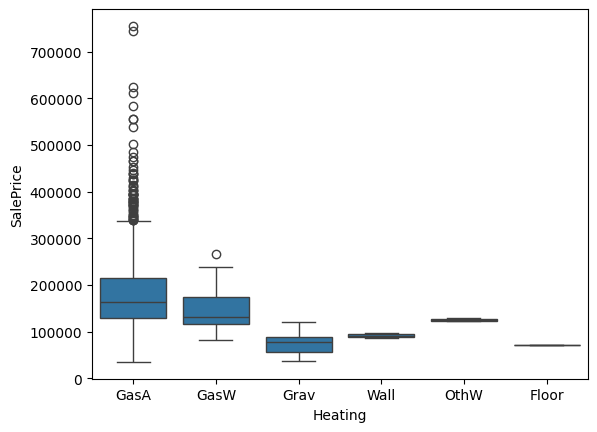

In [83]:
# Boxplots for skewed cat_cols

cat_cols_to_check = ["Street", "Utilities", "Condition2", "RoofMatl", "Heating"]

for col in cat_cols_to_check:
    sns.boxplot(data = df_test, x = col, y = "SalePrice")
    plt.show()

### Categorical feature engineering

In [84]:
df["Utilities"].value_counts()

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

Drop utilities as clearly too imbalance.

In [85]:
cols_to_drop.append("Utilities")

## EDA Conclusion

### Feature distributions

Many features, including the target variable are highly skewed. A log transform is appropriate for sale price while other features required converting into binary features, or dropping entirely. Below is a list of columns to be excluded from any model.

In [86]:
set(cols_to_drop)

{'BedroomAbvGr',
 'BsmtFinSF2',
 'BsmtFullBath',
 'BsmtHalfBath',
 'GarageYrBlt',
 'HalfBath',
 'KitchenAbvGr',
 'LowQualFinSF',
 'MiscVal',
 'Utilities',
 'YearBuilt',
 'YrSold'}

### Impact on model

While many outliers have been removed, the skewed features and strong feature-to-feature correlations suggest a tree based approach is suitable. The same feature engineering steps must be integrated into the pipeline.